# TabICL Survival Quickstart

The shortest path from a survival checkpoint to predictions. The wrapper is a
plain scikit-learn-style estimator: construct it, call `fit` on your context
rows, then predict.

```python
estimator = TabICLSurvivalEstimator(checkpoint_path, device="cpu")
estimator.fit(X_train, t=t_train, delta=delta_train)
```

`fit` does **not** train neural-network weights. It stores and preprocesses the
context set; each prediction conditions on that context in a single forward
pass (in-context learning).

This notebook covers:

1. Loading a checkpoint.
2. Fitting on a context set.
3. Predicting medians, quantiles, survival curves, and conditional survival.
4. When (and only when) to override the optional arguments.

## 1. Setup

Run this notebook from `tabicl-main/` or `tabicl-main/tutorials/`. The checkpoint
is discovered from the `TABICL_SURVIVAL_CHECKPOINT` environment variable, or from
`../checkpoints/step-5000.ckpt` / `checkpoints/step-5000.ckpt`.

In [1]:
from pathlib import Path
import os
import sys
import tempfile

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "tabicl_matplotlib_cache"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "tabicl").is_dir() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError(
        "Could not locate tabicl-main. Open this notebook from tabicl-main/ "
        "or from tabicl-main/tutorials/."
    )


REPO_ROOT = find_repo_root(Path.cwd().resolve())
PROJECT_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))


def resolve_checkpoint() -> Path:
    env_path = os.environ.get("TABICL_SURVIVAL_CHECKPOINT")
    candidates = []
    if env_path:
        candidates.append(Path(env_path).expanduser())
    candidates.extend([
        PROJECT_ROOT / "checkpoints" / "step-5000.ckpt",
        REPO_ROOT / "checkpoints" / "step-5000.ckpt",
    ])
    for candidate in candidates:
        if candidate.is_file():
            return candidate
    searched = "\n".join(f"  - {candidate}" for candidate in candidates)
    raise FileNotFoundError(
        "Could not find step-5000.ckpt.\n"
        "Set TABICL_SURVIVAL_CHECKPOINT=/path/to/step-5000.ckpt or place it at one of:\n"
        f"{searched}"
    )


from tabicl.survival import TabICLSurvivalEstimator

CHECKPOINT_PATH = resolve_checkpoint()
print(f"Checkpoint: {CHECKPOINT_PATH}")

Checkpoint: /Users/q24tian/Library/CloudStorage/GoogleDrive-qltian2021@gmail.com/Other computers/My Laptop/Documents/Research/ai/survival_icl/checkpoints/step-5000.ckpt


## 2. A Survival Dataset

Survival data is three aligned arrays:

- `X` — tabular covariates, shape `(n, p)`.
- `t` — observed time, `min(event_time, censoring_time)`.
- `delta` — event indicator: `1` if the event was observed, `0` if right-censored.

In your own workflow, replace this cell with your real `X`, `t`, and `delta`.
Here we generate a Weibull proportional-hazards dataset.

In [2]:
def make_weibull_ph_data(n=600, p=5, seed=20260608):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p)).astype(np.float32)
    beta = np.array([0.8, -0.6, 0.45, 0.0, 0.25], dtype=np.float32)[:p]
    eta = X @ beta
    shape, scale = 1.6, 10.0
    u = np.clip(rng.uniform(size=n), 1e-10, 1.0 - 1e-10)
    event_time = scale * (-np.log(u) / np.exp(eta)) ** (1.0 / shape)
    censor_time = rng.exponential(scale=18.0, size=n)
    t_obs = np.minimum(event_time, censor_time).astype(np.float32)
    delta = (event_time <= censor_time).astype(np.float32)
    X_df = pd.DataFrame(X, columns=[f"x{j}" for j in range(p)])
    return X_df, t_obs, delta


X, t_obs, delta = make_weibull_ph_data()

# Context = the rows the model conditions on. Query = new units to predict.
n_train = 450
X_train, t_train, delta_train = X.iloc[:n_train], t_obs[:n_train], delta[:n_train]
X_query = X.iloc[n_train:]

print(f"Context rows: {len(X_train)}  (event rate {delta_train.mean():.2f})")
print(f"Query rows:   {len(X_query)}")
X_train.head()

Context rows: 450  (event rate 0.61)
Query rows:   150


,x0,x1,x2,x3,x4
0,-1.264776,0.003252,-0.053370,0.249075,-0.236105
1,-1.525471,-1.535463,-0.120400,-1.589398,0.192241
2,1.890808,-0.981981,0.455801,-0.082035,0.296225
3,-0.086594,0.400522,-0.470893,-0.581323,1.364267
4,-0.167677,-0.624161,0.646632,0.257909,0.050109


## 3. Fit — Two Lines

Construct with just the checkpoint path and device, then `fit` on the context
set. No other arguments are needed: by default the wrapper uses **all** context
rows and a sensible query batch size.

In [3]:
estimator = TabICLSurvivalEstimator(CHECKPOINT_PATH, device="cpu")
estimator.fit(X_train, t=t_train, delta=delta_train)

print(f"Context rows used: {len(estimator.context_indices_)}")
print(f"Features: {estimator.n_features_in_}")

Context rows used: 450
Features: 5


## 4. Median and Quantile Event Times

`predict` returns the median predicted event time. `predict_quantiles` returns
arbitrary event-time quantiles, all in raw time units.

In [4]:
rows = X_query.iloc[:5]

median = estimator.predict(rows)
quantiles = estimator.predict_quantiles(rows, quantile_levels=(0.1, 0.25, 0.5, 0.75, 0.9))

table = pd.DataFrame(quantiles, columns=["q0.10", "q0.25", "q0.50", "q0.75", "q0.90"])
table.insert(0, "median", median)
table.round(2)

,median,q0.10,q0.25,q0.50,q0.75,q0.90
0,3.49,0.78,1.74,3.49,6.01,9.03
1,4.24,0.95,2.11,4.24,7.33,11.08
2,8.70,1.97,4.31,8.70,15.01,22.39
3,3.54,0.78,1.75,3.54,6.19,9.41
4,3.31,0.74,1.65,3.31,5.71,8.56


## 5. Survival Curves

`predict_survival_function(X, times=...)` returns `S(t | X)` evaluated at the
times you ask for, one row per query unit.

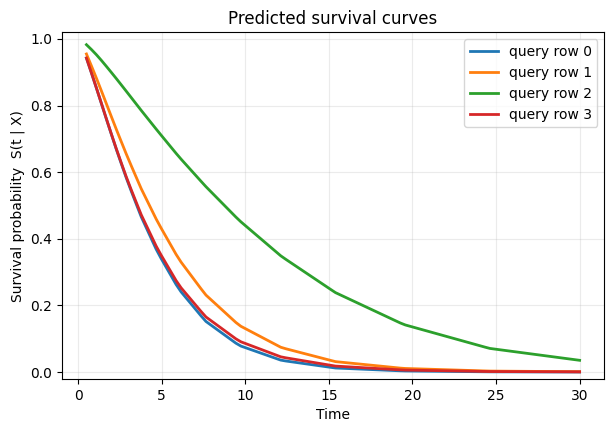

In [5]:
times = np.linspace(0.5, 30.0, 100, dtype=np.float32)
curves = estimator.predict_survival_function(X_query.iloc[:4], times=times)

plt.figure(figsize=(7, 4.5))
for i, curve in enumerate(curves):
    plt.plot(times, curve, linewidth=2, label=f"query row {i}")
plt.ylim(-0.02, 1.02)
plt.xlabel("Time")
plt.ylabel("Survival probability  S(t | X)")
plt.title("Predicted survival curves")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 6. Survival Probability at Specific Horizons

Ask the same method for a few specific times to answer questions like
"what is the probability this unit is still event-free at t = 5, 10, 20?"
Event probability is just `1 - S(t | X)`.

In [6]:
horizons = np.array([5.0, 10.0, 20.0], dtype=np.float32)
surv = estimator.predict_survival_function(X_query.iloc[:5], times=horizons)

prob_table = pd.DataFrame(surv, columns=[f"S(t={h:g})" for h in horizons])
for j, h in enumerate(horizons):
    prob_table[f"event(t={h:g})"] = 1.0 - surv[:, j]
prob_table.round(3)

,S(t=5),S(t=10),S(t=20),event(t=5),event(t=10),event(t=20)
0,0.338,0.073,0.003,0.662,0.927,0.997
1,0.429,0.130,0.010,0.571,0.870,0.990
2,0.709,0.440,0.135,0.291,0.560,0.865
3,0.348,0.086,0.006,0.652,0.914,0.994
4,0.313,0.061,0.002,0.687,0.939,0.998


## 7. Conditional Survival After a Landmark

If a unit is known to be event-free up to time `c`, the conditional survival
curve is

$$S(t \mid T > c, X) = \begin{cases} 1 & t \le c \\ S(t \mid X) / S(c \mid X) & t > c. \end{cases}$$

Pass `conditional_time` to apply this. The landmark time is **not** added to the
model prompt; it is a post-model transformation of the survival curve.

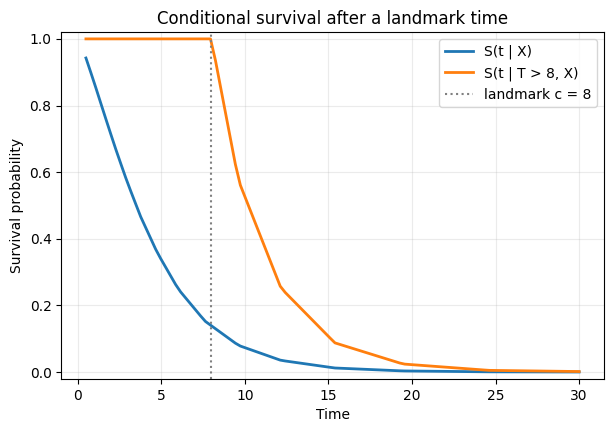

In [7]:
x_landmark = X_query.iloc[[0]]
c = 8.0

uncond = estimator.predict_survival_function(x_landmark, times=times)[0]
cond = estimator.predict_survival_function(
    x_landmark, times=times, conditional_time=np.array([c], dtype=np.float32),
)[0]

plt.figure(figsize=(7, 4.5))
plt.plot(times, uncond, linewidth=2, label="S(t | X)")
plt.plot(times, cond, linewidth=2, label=f"S(t | T > {c:g}, X)")
plt.axvline(c, color="gray", linestyle=":", label=f"landmark c = {c:g}")
plt.ylim(-0.02, 1.02)
plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.title("Conditional survival after a landmark time")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 8. When to Override the Defaults

You usually only pass `checkpoint_path` and `device`. The two optional knobs:

| Argument | Default | Override when |
|---|---|---|
| `max_context_size` | `None` (use all context rows) | Your context set is larger than the checkpoint's training sequence length (~1,024 total positions for a Stage-1 checkpoint, ~60,000 for Stage-3). Set an integer cap to deterministically subsample and stay in-distribution. |
| `query_batch_size` | `512` | You hit out-of-memory on a large query set (lower it), or you have spare RAM/VRAM and want fewer forward passes (raise it). |

```python
# Example: cap a very large context set and shrink query batches for low memory.
estimator = TabICLSurvivalEstimator(
    CHECKPOINT_PATH,
    device="cpu",
    max_context_size=1000,
    query_batch_size=128,
)
```

Other useful entry points on the fitted estimator:

- `fit(X, y)` also accepts `y` as a two-column `[time, event]` array or a
  `{"time": ..., "event": ...}` dict instead of `t=`/`delta=`.
- `predict_survival_function(..., return_times=True)` returns the checkpoint's
  own raw time grid alongside the curves when you omit `times`.